# Angular Spectrum Convergence Study

This notebook investigates how RMSE converges for the angular spectrum method as we vary:
1. **N_photons**: Number of Monte Carlo samples
2. **FFT resolution**: K-space sampling resolution (fft_size)

For each combination, we run multiple trials and compute mean ± std of RMSE.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1
from scipy.interpolate import interp1d
from monte_carlo.angular_spectrum import AngularSpectrumSimulator
from monte_carlo import metrics

# Set style
sns.set_theme(style="whitegrid", font_scale=1.5)

# Create output directory
import os
output_dir = '../data/angular_spectrum_convergence'
os.makedirs(output_dir, exist_ok=True)

# Helper function to compute FWHM
def compute_fwhm(r_centers, intensity):
    """
    Compute Full Width at Half Maximum (FWHM) from radial intensity profile.
    
    Parameters
    ----------
    r_centers : np.ndarray
        Radial distance values
    intensity : np.ndarray
        Normalized intensity values (peak = 1.0)
    
    Returns
    -------
    float
        FWHM value (diameter at half maximum)
    """
    # Find where intensity crosses 0.5
    half_max = 0.5
    
    # Find indices where intensity is above half max
    above_half = intensity >= half_max
    
    if not np.any(above_half):
        return np.nan
    
    # Find the last point above half max (going outward from center)
    try:
        # Find approximate crossing point
        crossing_idx = np.where(np.diff(above_half.astype(int)) < 0)[0]
        
        if len(crossing_idx) == 0:
            return np.nan
        
        # Use first crossing (going outward from center)
        idx = crossing_idx[0]
        
        # Refine with linear interpolation
        r_range = r_centers[idx:idx+2]
        i_range = intensity[idx:idx+2] - half_max
        
        # Linear interpolation to find zero crossing
        r_half_max = r_range[0] - i_range[0] * (r_range[1] - r_range[0]) / (i_range[1] - i_range[0])
        
        fwhm = 2 * r_half_max
        return fwhm
    except:
        return np.nan

## Setup Parameters

In [ ]:
# Fixed simulation parameters
wavelength = 0.6328  # microns (632.8 nm - HeNe laser)
focal_length = 10.0  # mm
numerical_aperture = 0.1
n_medium = 1.0

# Convergence study parameters
n_photons_list = [1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000]
fft_sizes = [256, 512, 1024, 2048, 4096, 8192, 16384]  # Extended: x2, x2, x2 from 2048
n_trials = 10  # Number of trials per combination

# Airy parameters
airy_radius = 1.22 * wavelength / numerical_aperture
k_theory = 2 * np.pi * numerical_aperture / wavelength

print(f"Wavelength: {wavelength} μm ({wavelength*1000:.1f} nm)")
print(f"NA: {numerical_aperture}")
print(f"Focal length: {focal_length} mm")
print(f"First Airy zero: {airy_radius:.4f} μm")
print(f"\nN_photons range: {min(n_photons_list)} to {max(n_photons_list)}")
print(f"FFT sizes: {fft_sizes}")
print(f"Trials per combination: {n_trials}")
print(f"Total simulations: {len(fft_sizes)} FFT × {len(n_photons_list)} n_photons × {n_trials} trials = {len(fft_sizes)*len(n_photons_list)*n_trials}")

## Compute Theoretical Airy Pattern

In [3]:
# Create theoretical Airy radial profile
plot_range = 2 * airy_radius
r_bins = np.linspace(0, plot_range, 300)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
bin_areas = np.pi * (r_bins[1:]**2 - r_bins[:-1]**2)

# Theoretical Airy pattern
kr_theory = k_theory * r_centers
airy_theory = np.ones_like(kr_theory)
nonzero = kr_theory != 0
airy_theory[nonzero] = (2 * j1(kr_theory[nonzero]) / kr_theory[nonzero])**2

print(f"Radial bins: {len(r_bins)}")
print(f"Radial range: [0, {plot_range:.4f}] μm")

Radial bins: 300
Radial range: [0, 15.4403] μm


## Run Convergence Study

In [4]:
# Storage for results: {fft_size: {n_photons: {'mean': x, 'std': y, 'trials': []}}}
rmse_results = {fft_size: {} for fft_size in fft_sizes}
fwhm_results = {fft_size: {} for fft_size in fft_sizes}

# Compute theoretical FWHM
fwhm_theory = compute_fwhm(r_centers, airy_theory)
print(f"Theoretical Airy FWHM: {fwhm_theory:.4f} μm\n")

for fft_size in fft_sizes:
    print(f"\n{'='*80}")
    print(f"FFT Size = {fft_size}")
    print(f"{'='*80}")
    
    for n_photons in n_photons_list:
        print(f"  N_photons = {n_photons}...")
        rmse_trials = []
        fwhm_trials = []
        
        # Create subdirectory for this combination
        combo_dir = f'{output_dir}/fft_{fft_size}_n_photons_{n_photons}'
        os.makedirs(combo_dir, exist_ok=True)
        
        for trial in range(n_trials):
            # Create simulator with different seed for each trial
            sim = AngularSpectrumSimulator(
                n_photons=n_photons,
                wavelength=wavelength,
                focal_length=focal_length,
                numerical_aperture=numerical_aperture,
                n_medium=n_medium,
                random_seed=trial,
                fft_size=fft_size
            )
            
            # Run simulation
            results = sim.propagate()
            x, y, _ = results['focal_positions']
            
            # Compute radial profile
            r = np.sqrt(x**2 + y**2)
            hist_r, _ = np.histogram(r, bins=r_bins)
            intensity_r = hist_r / bin_areas
            intensity_r = intensity_r / np.max(intensity_r)  # Normalize to peak
            
            # Compute RMSE
            rmse_val = metrics.rmse(intensity_r, airy_theory)
            rmse_trials.append(rmse_val)
            
            # Compute FWHM
            fwhm_val = compute_fwhm(r_centers, intensity_r)
            fwhm_trials.append(fwhm_val)
            
            # Save comparison plot for this trial
            fig, ax = plt.subplots(1, 1, figsize=(10, 7))
            ax.plot(r_centers, airy_theory, 'r-', linewidth=3, label='Theoretical Airy', alpha=0.8)
            ax.plot(r_centers, intensity_r, 'b-', linewidth=2, label=f'Monte Carlo (Trial {trial+1})', alpha=0.7)
            ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1.5, label='Half Maximum')
            ax.set_xlabel('Radial Distance (μm)', fontsize=14)
            ax.set_ylabel('Normalized Intensity', fontsize=14)
            ax.set_title(f'Focal Plane: Airy vs Monte Carlo\nFFT={fft_size}, N_photons={n_photons}, Trial {trial+1}\nRMSE={rmse_val:.6f}, FWHM={fwhm_val:.4f} μm (theory: {fwhm_theory:.4f} μm)', 
                         fontsize=12, fontweight='bold')
            ax.legend(fontsize=12)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f'{combo_dir}/trial_{trial+1:02d}_comparison.png', dpi=150, bbox_inches='tight')
            plt.close()
        
        # Store results
        rmse_results[fft_size][n_photons] = {
            'mean': np.mean(rmse_trials),
            'std': np.std(rmse_trials),
            'trials': rmse_trials
        }
        
        fwhm_trials_clean = [f for f in fwhm_trials if not np.isnan(f)]
        fwhm_results[fft_size][n_photons] = {
            'mean': np.mean(fwhm_trials_clean) if len(fwhm_trials_clean) > 0 else np.nan,
            'std': np.std(fwhm_trials_clean) if len(fwhm_trials_clean) > 0 else np.nan,
            'trials': fwhm_trials,
            'error_vs_theory': np.abs(np.mean(fwhm_trials_clean) - fwhm_theory) if len(fwhm_trials_clean) > 0 else np.nan
        }
        
        print(f"    RMSE: {rmse_results[fft_size][n_photons]['mean']:.6f} ± {rmse_results[fft_size][n_photons]['std']:.6f}")
        print(f"    FWHM: {fwhm_results[fft_size][n_photons]['mean']:.4f} ± {fwhm_results[fft_size][n_photons]['std']:.4f} μm (error: {fwhm_results[fft_size][n_photons]['error_vs_theory']:.4f} μm)")
        print(f"    Saved {n_trials} comparison images to {combo_dir}/")

print("\nConvergence study complete!")

Theoretical Airy FWHM: 3.2557 μm


FFT Size = 256
  N_photons = 1000...


    RMSE: 0.141184 ± 0.028611
    FWHM: 0.4135 ± 0.4791 μm (error: 2.8422 μm)
    Saved 10 comparison images to ../data/angular_spectrum_convergence/fft_256_n_photons_1000/
  N_photons = 5000...


    RMSE: 0.099538 ± 0.019925
    FWHM: 1.8847 ± 0.6679 μm (error: 1.3710 μm)
    Saved 10 comparison images to ../data/angular_spectrum_convergence/fft_256_n_photons_5000/
  N_photons = 10000...


    RMSE: 0.086522 ± 0.016137
    FWHM: 2.2299 ± 0.2815 μm (error: 1.0259 μm)
    Saved 10 comparison images to ../data/angular_spectrum_convergence/fft_256_n_photons_10000/
  N_photons = 50000...


    RMSE: 0.073758 ± 0.006288
    FWHM: 2.3796 ± 0.0912 μm (error: 0.8762 μm)
    Saved 10 comparison images to ../data/angular_spectrum_convergence/fft_256_n_photons_50000/
  N_photons = 100000...


...

    RMSE: 0.035966 ± 0.011091
    FWHM: 2.9731 ± 0.1623 μm (error: 0.2827 μm)
    Saved 10 comparison images to ../data/angular_spectrum_convergence/fft_2048_n_photons_50000/
  N_photons = 100000...


    RMSE: 0.028431 ± 0.006029
    FWHM: 3.0604 ± 0.0479 μm (error: 0.1953 μm)
    Saved 10 comparison images to ../data/angular_spectrum_convergence/fft_2048_n_photons_100000/
  N_photons = 500000...


    RMSE: 0.025099 ± 0.005471
    FWHM: 3.0733 ± 0.0410 μm (error: 0.1824 μm)
    Saved 10 comparison images to ../data/angular_spectrum_convergence/fft_2048_n_photons_500000/
  N_photons = 1000000...


    RMSE: 0.023212 ± 0.003426
    FWHM: 3.0882 ± 0.0215 μm (error: 0.1675 μm)
    Saved 10 comparison images to ../data/angular_spectrum_convergence/fft_2048_n_photons_1000000/
  N_photons = 5000000...


    RMSE: 0.023050 ± 0.002912
    FWHM: 3.0867 ± 0.0196 μm (error: 0.1690 μm)
    Saved 10 comparison images to ../data/angular_spectrum_convergence/fft_2048_n_photons_5000000/

Convergence study complete!


## Plot Results

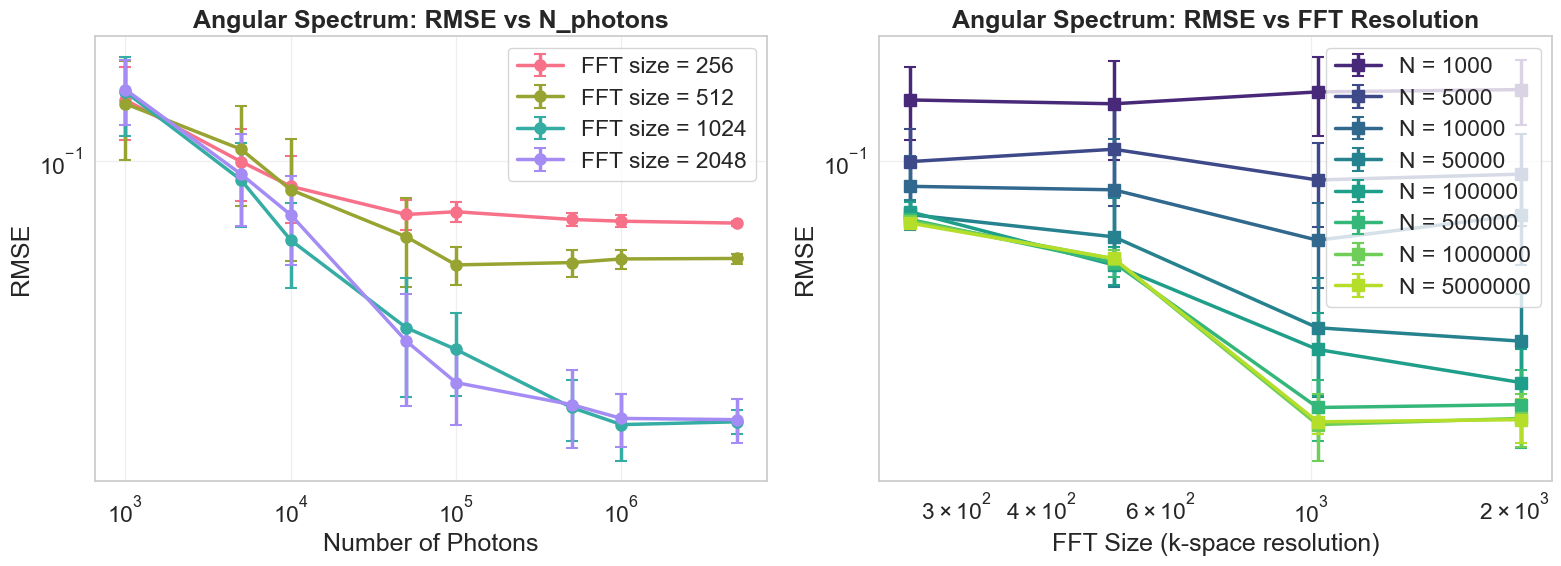


Plot saved to: ../data/angular_spectrum_convergence/angular_spectrum_convergence.png


In [5]:
# Create figure with multiple lines for different FFT sizes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color palette
colors = sns.color_palette("husl", len(fft_sizes))

# Plot 1: RMSE vs N_photons for different FFT sizes
ax = axes[0]
for i, fft_size in enumerate(fft_sizes):
    n_photons_array = np.array(n_photons_list)
    rmse_mean = np.array([rmse_results[fft_size][n]['mean'] for n in n_photons_list])
    rmse_std = np.array([rmse_results[fft_size][n]['std'] for n in n_photons_list])
    
    ax.errorbar(n_photons_array, rmse_mean, yerr=rmse_std, 
                marker='o', markersize=8, linewidth=2.5, capsize=4, capthick=1.5,
                label=f'FFT size = {fft_size}', color=colors[i])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Photons')
ax.set_ylabel('RMSE')
ax.set_title('Angular Spectrum: RMSE vs N_photons', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: RMSE vs FFT size for different N_photons
ax = axes[1]
colors2 = sns.color_palette("viridis", len(n_photons_list))

for i, n_photons in enumerate(n_photons_list):
    fft_array = np.array(fft_sizes)
    rmse_mean = np.array([rmse_results[fft][n_photons]['mean'] for fft in fft_sizes])
    rmse_std = np.array([rmse_results[fft][n_photons]['std'] for fft in fft_sizes])
    
    ax.errorbar(fft_array, rmse_mean, yerr=rmse_std,
                marker='s', markersize=8, linewidth=2.5, capsize=4, capthick=1.5,
                label=f'N = {n_photons}', color=colors2[i])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('FFT Size (k-space resolution)')
ax.set_ylabel('RMSE')
ax.set_title('Angular Spectrum: RMSE vs FFT Resolution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/angular_spectrum_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {output_dir}/angular_spectrum_convergence.png")

## Summary Statistics

In [6]:
print("\n" + "="*120)
print("ANGULAR SPECTRUM CONVERGENCE STUDY")
print("="*120)
print(f"Theoretical Airy FWHM: {fwhm_theory:.4f} μm")
print("="*120)

for fft_size in fft_sizes:
    print(f"\nFFT Size = {fft_size}")
    print("-"*120)
    print(f"{'N_photons':<12} {'RMSE (mean)':<15} {'RMSE (std)':<15} {'FWHM (mean)':<15} {'FWHM (std)':<15} {'FWHM Error':<15} {'Rel Std %':<12}")
    print("-"*120)
    for n in n_photons_list:
        mean_rmse = rmse_results[fft_size][n]['mean']
        std_rmse = rmse_results[fft_size][n]['std']
        mean_fwhm = fwhm_results[fft_size][n]['mean']
        std_fwhm = fwhm_results[fft_size][n]['std']
        fwhm_err = fwhm_results[fft_size][n]['error_vs_theory']
        rel_std = (std_rmse / mean_rmse) * 100 if mean_rmse > 0 else 0
        print(f"{n:<12} {mean_rmse:<15.6f} {std_rmse:<15.6f} {mean_fwhm:<15.4f} {std_fwhm:<15.4f} {fwhm_err:<15.4f} {rel_std:<12.2f}")

print("\n" + "="*120)


ANGULAR SPECTRUM CONVERGENCE STUDY
Theoretical Airy FWHM: 3.2557 μm

FFT Size = 256
------------------------------------------------------------------------------------------------------------------------
N_photons    RMSE (mean)     RMSE (std)      FWHM (mean)     FWHM (std)      FWHM Error      Rel Std %   
------------------------------------------------------------------------------------------------------------------------
1000         0.141184        0.028611        0.4135          0.4791          2.8422          20.27       
5000         0.099538        0.019925        1.8847          0.6679          1.3710          20.02       
10000        0.086522        0.016137        2.2299          0.2815          1.0259          18.65       
50000        0.073758        0.006288        2.3796          0.0912          0.8762          8.52        
100000       0.074918        0.004318        2.3802          0.0793          0.8755          5.76        
500000       0.071706        0.002758